load the data

In [125]:
# Data Handling & Analysis
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Google Colab Utilities
from google.colab import files

# Machine Learning - Model Building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans

# Machine Learning - Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler

In [126]:


uploade = files.upload()
df = pd.read_csv('supply_chain_data.csv')

Saving supply_chain_data.csv to supply_chain_data (1).csv


In [127]:
df.head()


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Order Lead times,Order quantities,...,Location,Shipping Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [128]:
df_copy = df.copy()

In [129]:
df_copy.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Order Lead times,Order quantities,...,Location,Shipping Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [130]:
df_copy.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Order Lead times,0
Order quantities,0


In [131]:
df_copy.duplicated().sum()

np.int64(0)

data cleaning & data transformaiton

In [132]:
df_copy.shape # here i have 100 rows and 24 columns

(100, 24)

In [133]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Order Lead times         100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [134]:
df_copy.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Order Lead times,Order quantities,Shipping times,Shipping costs,Shipping Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239830,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976920,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [135]:
df_copy.columns

Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Order Lead times', 'Order quantities',
       'Shipping times', 'Shipping carriers', 'Shipping costs',
       'Supplier name', 'Location', 'Shipping Lead time', 'Production volumes',
       'Manufacturing lead time', 'Manufacturing costs', 'Inspection results',
       'Defect rates', 'Transportation modes', 'Routes', 'Costs'],
      dtype='object')

In [136]:
# Text / Categorical columns
text_cols = df.select_dtypes(include='object').columns

# Numerical columns
num_cols = df.select_dtypes(include='number').columns

print("Text / String Columns:", len(text_cols))
print(text_cols.tolist())

print("\nNumerical Columns:", len(num_cols))
print(num_cols.tolist())

Text / String Columns: 9
['Product type', 'SKU', 'Customer demographics', 'Shipping carriers', 'Supplier name', 'Location', 'Inspection results', 'Transportation modes', 'Routes']

Numerical Columns: 15
['Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Order Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Shipping Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs']


first we change all col names -> snake_case

In [137]:
df_copy.columns = (
    df.columns
      .str.strip()              # remove extra spaces
      .str.lower()              # lowercase
      .str.replace(' ', '_')    # space → underscore
      .str.replace('-', '_')    # dash → underscore
)

In [138]:
df_copy[df_copy.duplicated(subset=['sku'], keep=False)]

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,order_lead_times,order_quantities,...,location,shipping_lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs


In [139]:
df_copy.head(3)

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,order_lead_times,order_quantities,...,location,shipping_lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282


We analyse whole supply chain data into 4 parts.
- Demand / Sales
- Inventory
- supplies
- Logistic

## Demand / Sales

In [140]:
# Total demand & total sales

total_units_sold = df_copy['number_of_products_sold'].sum()
total_revenue = df_copy['revenue_generated'].sum()

print('Total Unite sold : ',total_units_sold)
print('Total Sales : ',total_revenue)

Total Unite sold :  46099
Total Sales :  577604.8187399999


In [141]:
# product type wise product sold

product_type_sales = df_copy.groupby('product_type')['number_of_products_sold'].sum()
product_type_sales

,number_of_products_sold
product_type,
cosmetics,11757
haircare,13611
skincare,20731


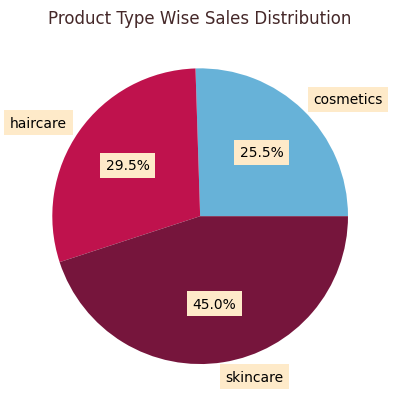

In [142]:
import matplotlib.pyplot as plt

# Group data
product_type_sales = df_copy.groupby('product_type')['number_of_products_sold'].sum()

# Given colors
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

# Create pie chart
plt.figure()
plt.pie(
    product_type_sales,
    labels=product_type_sales.index,
    colors=colors[:len(product_type_sales)],
    autopct='%1.1f%%',
    textprops={
        'color': 'black',
        'bbox': dict(facecolor='#FEEAC9', edgecolor='none')
    }
)

# Title styling
plt.title(
    'Product Type Wise Sales Distribution',
    color='#452829'
)

# White background
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

plt.show()

In [143]:
# top product sell
top_sell_product = product_type_sales.sort_values(ascending=False).head(1)
top_sell_product

,number_of_products_sold
product_type,
skincare,20731


In [144]:
# revenue generate product type

top_product_revenue = df_copy.groupby('product_type')['revenue_generated'].sum()
top_product_revenue

,revenue_generated
product_type,
cosmetics,161521.266001
haircare,174455.390606
skincare,241628.162133


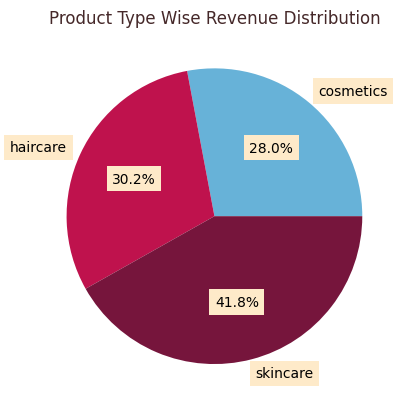

In [145]:

# Colors you provided
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()
plt.pie(
    top_product_revenue,
    labels=top_product_revenue.index,
    colors=colors[:len(top_product_revenue)],
    autopct='%1.1f%%',
    textprops={
        'color': 'black',
        'bbox': dict(facecolor='#FEEAC9', edgecolor='none')
    }
)

plt.title(
    'Product Type Wise Revenue Distribution',
    color='#452829'
)

# White background
plt.gca().set_facecolor('white')
plt.gcf().set_facecolor('white')

plt.show()

In [146]:
# top revenue generator product

top_revenue_product = top_product_revenue.sort_values(ascending=False).head(1)
top_revenue_product

,revenue_generated
product_type,
skincare,241628.162133


In [147]:
# correlaiton of price and product sold

df_copy[['price', 'number_of_products_sold']].corr()

,price,number_of_products_sold
price,1.000000,0.005739
number_of_products_sold,0.005739,1.000000


- Here the correlation is 0.005739 which means there is no significant relationship between price and demand.

- Demand appears to be influenced more by non-price factors such as availability and supply chain efficiency.

In [148]:
df_copy['number_of_products_sold'].min(), df_copy['number_of_products_sold'].max()


(8, 996)

Demand Level	Units Sold

Low	8 - 100

Medium	101 - 500

High	501 - 996

In [149]:
df_copy['demand_level'] = 'Low Demand'

df_copy.loc[df_copy['number_of_products_sold'] > 100, 'demand_level'] = 'Medium Demand'
df_copy.loc[df_copy['number_of_products_sold'] > 500, 'demand_level'] = 'High Demand'

In [150]:
df_copy['demand_level']

,demand_level
0,High Demand
1,High Demand
2,Low Demand
3,Low Demand
4,High Demand
...,...
95,High Demand
96,Medium Demand
97,Low Demand
98,High Demand


In [151]:
df_copy['demand_level'].value_counts()

,count
demand_level,
Medium Demand,46
High Demand,43
Low Demand,11


In [152]:
print('STD SALES : ',df_copy['number_of_products_sold'].std())
print('AVG SALES : ',df_copy['number_of_products_sold'].mean())

STD SALES :  303.780073790766
AVG SALES :  460.99


In [153]:
cv = (df_copy['number_of_products_sold'].std() / df_copy['number_of_products_sold'].mean())*100
print(cv)

65.89732397465585


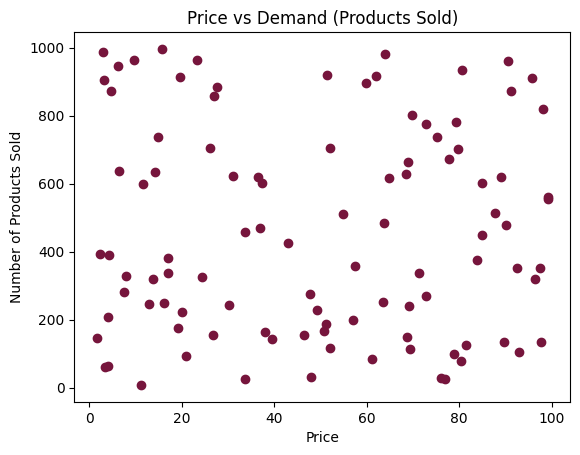

In [154]:
plt.figure()
plt.scatter(
    df_copy['price'],
    df_copy['number_of_products_sold'],
    color='#76153C'   # choose any one from your list
)
plt.xlabel('Price')
plt.ylabel('Number of Products Sold')
plt.title('Price vs Demand (Products Sold)')
plt.show()

- Demand is spread across all price levels, showing that price alone does not strongly control how much a product sells.

- At similar prices, sales range from very low to very high, confirming unstable and unpredictable demand behavior.

In [155]:
# product count
product_count = (
    df_copy.groupby('product_type')['sku']
           .nunique()
           .reset_index(name='total_products')
)

product_count

,product_type,total_products
0,cosmetics,26
1,haircare,34
2,skincare,40


In [156]:
df_copy.groupby('customer_demographics')['number_of_products_sold'] \
       .sum() \
       .sort_values(ascending=False)

,number_of_products_sold
customer_demographics,
Unknown,15211
Female,12801
Non-binary,10580
Male,7507


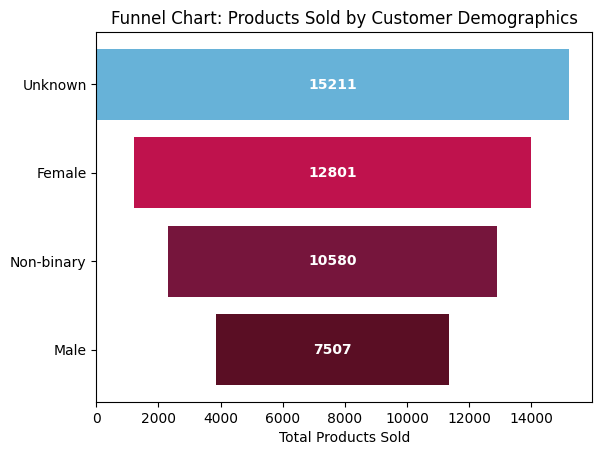

In [157]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
demo_sales = (
    df_copy.groupby('customer_demographics')['number_of_products_sold']
           .sum()
           .sort_values(ascending=False)
)

labels = demo_sales.index.tolist()
values = demo_sales.values.tolist()

# Funnel positioning (center alignment)
max_value = max(values)
left_positions = [(max_value - v) / 2 for v in values]

# Your 4 rose-pink colors
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

bars = plt.barh(
    labels,
    values,
    left=left_positions,
    color=colors[:len(values)]
)

# Add value labels inside bars
for bar, value, left in zip(bars, values, left_positions):
    plt.text(
        left + value / 2,
        bar.get_y() + bar.get_height() / 2,
        f'{value}',
        va='center',
        ha='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.gca().invert_yaxis()
plt.title('Funnel Chart: Products Sold by Customer Demographics')
plt.xlabel('Total Products Sold')

plt.show()

In [158]:
df_copy.groupby('customer_demographics')['revenue_generated'] \
       .sum() \
       .sort_values(ascending=False)

,revenue_generated
customer_demographics,
Unknown,173090.133841
Female,161514.489121
Male,126634.394260
Non-binary,116365.801518


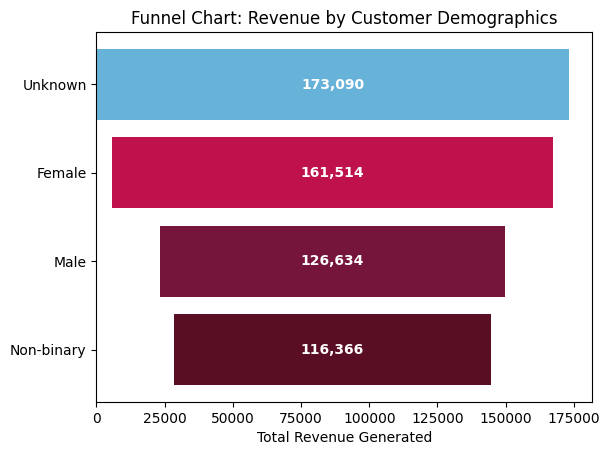

In [159]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
demo_revenue = (
    df_copy.groupby('customer_demographics')['revenue_generated']
           .sum()
           .sort_values(ascending=False)
)

labels = demo_revenue.index.tolist()
values = demo_revenue.values.tolist()

# Funnel positioning (center alignment)
max_value = max(values)
left_positions = [(max_value - v) / 2 for v in values]

# Your 4 rose-pink colors
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

bars = plt.barh(
    labels,
    values,
    left=left_positions,
    color=colors[:len(values)]
)

# Add value labels inside funnel bars
for bar, value, left in zip(bars, values, left_positions):
    plt.text(
        left + value / 2,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,.0f}',
        ha='center',
        va='center',
        color='white',
        fontsize=10,
        fontweight='bold'
    )

plt.gca().invert_yaxis()
plt.xlabel('Total Revenue Generated')
plt.title('Funnel Chart: Revenue by Customer Demographics')

plt.show()

In [160]:
df_copy.groupby('customer_demographics')['number_of_products_sold'].std() \
       .sort_values(ascending=False)

,number_of_products_sold
customer_demographics,
Female,334.075775
Non-binary,299.520678
Unknown,289.202511
Male,287.841731


In [161]:
df_copy.head(2)

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,order_lead_times,order_quantities,...,shipping_lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,demand_level
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,High Demand
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,High Demand


In [162]:
sku_availability = (
    df_copy.groupby('sku')['availability']
           .sum()
           .sort_values(ascending=False)
)

sku_availability

,availability
sku,
SKU19,100
SKU84,99
SKU42,98
SKU40,97
SKU94,97
...,...
SKU13,5
SKU37,5
SKU29,3


low avalibility products

In [163]:
low_stock_skus_unique = (
    df_copy[df_copy['availability'] < 20]
    [['sku', 'product_type', 'availability']]

)

low_stock_skus_unique

,sku,product_type,availability
10,SKU10,skincare,11
13,SKU13,skincare,5
26,SKU26,haircare,9
28,SKU28,cosmetics,12
29,SKU29,cosmetics,3
30,SKU30,haircare,10
35,SKU35,cosmetics,11
37,SKU37,skincare,5
43,SKU43,haircare,6
45,SKU45,haircare,1


In [164]:
X = df_copy.drop(columns=['number_of_products_sold'])
y = df_copy['number_of_products_sold']

In [165]:
X = pd.get_dummies(X, drop_first=True)

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [167]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [168]:
y_pred = model.predict(X_test)

In [169]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae, rmse, r2

(164.39698009474372, np.float64(186.29769349890026), 0.6363169330700468)

- The model explains about 64% of demand variation (R² = 0.636), which is solid performance given the highly volatile sales pattern.

- On average, its prediction can be off by about 160–180 units, which is okay because sales numbers go from very small to very large.

In [170]:
df_copy

,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,order_lead_times,order_quantities,...,shipping_lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs,demand_level
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,High Demand
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,High Demand
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,Low Demand
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,Low Demand
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,High Demand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241,High Demand
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141,Medium Demand
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423,Low Demand
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864,High Demand


## INVENTORY

In [171]:
# Total Available Inventory
total_inventory = df_copy['availability'].sum()
total_inventory

np.int64(4840)

In [172]:
# Inventory by Product Type
inventory_by_product = (
    df_copy.groupby('product_type')['availability']
           .sum()
           .sort_values(ascending=False)
)

inventory_by_product

,availability
product_type,
skincare,2037
haircare,1471
cosmetics,1332


In [173]:
# High Demand but Low Inventory
stockout_risk = df_copy[
    (df_copy['availability'] < 20) &
    (df_copy['number_of_products_sold'] > df_copy['number_of_products_sold'].mean())
][['sku', 'product_type', 'availability', 'number_of_products_sold']]

stockout_risk

,sku,product_type,availability,number_of_products_sold
10,SKU10,skincare,11,996
37,SKU37,skincare,5,963
43,SKU43,haircare,6,598
52,SKU52,skincare,1,820
54,SKU54,haircare,11,622
55,SKU55,haircare,16,701
67,SKU67,skincare,16,513
71,SKU71,cosmetics,14,637
81,SKU81,haircare,9,774
99,SKU99,haircare,17,627


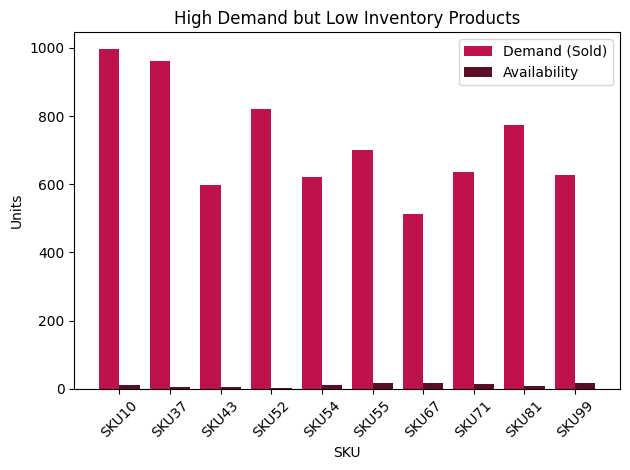

In [174]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare positions
x = np.arange(len(stockout_risk))

# Your rose-pink color palette
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

# Bars
plt.bar(
    x - 0.2,
    stockout_risk['number_of_products_sold'],
    width=0.4,
    label='Demand (Sold)',
    color=colors[1]   # #BF124D
)

plt.bar(
    x + 0.2,
    stockout_risk['availability'],
    width=0.4,
    label='Availability',
    color=colors[3]   # #5A0E24
)

# Axis & labels
plt.xticks(x, stockout_risk['sku'], rotation=45)
plt.xlabel('SKU')
plt.ylabel('Units')
plt.title('High Demand but Low Inventory Products')

plt.legend()
plt.tight_layout()
plt.show()

In [175]:
df_copy[['availability', 'number_of_products_sold']].corr()

,availability,number_of_products_sold
availability,1.000000,0.087496
number_of_products_sold,0.087496,1.000000


In [176]:
# HIGHEST stock levels
highest_stock = df_copy.loc[
    df_copy['stock_levels'].idxmax(),
    ['sku', 'product_type', 'stock_levels']
]

highest_stock

,12
sku,SKU12
product_type,haircare
stock_levels,100


In [177]:
# LOWEST STOCK LEVEL
lowest_stock = df_copy.loc[
    df_copy['stock_levels'].idxmin(),
    ['sku', 'product_type', 'stock_levels']
]

lowest_stock

,68
sku,SKU68
product_type,haircare
stock_levels,0


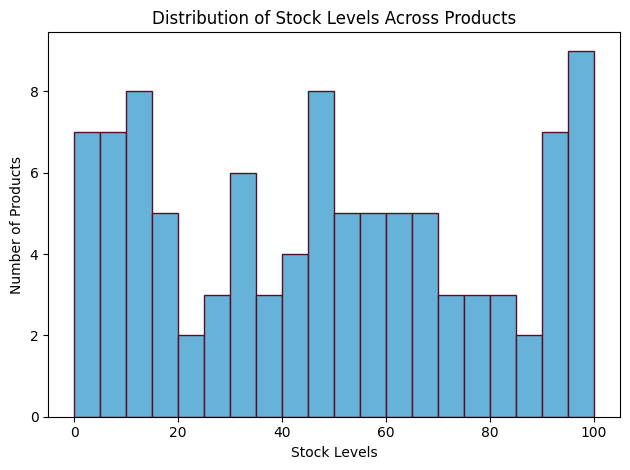

In [178]:
# DISTRIBUTION OF STOCK LEVELS
import matplotlib.pyplot as plt

# Your rose-pink color palette
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.hist(
    df_copy['stock_levels'],
    bins=20,
    color=colors[0],     # soft rose-blue tone
    edgecolor=colors[3] # dark wine border
)

plt.xlabel('Stock Levels')
plt.ylabel('Number of Products')
plt.title('Distribution of Stock Levels Across Products')

plt.tight_layout()
plt.show()

In [179]:
# TOP 5 PRODUCT WITH PRODUCT TYPE & STOKC LEVLE

df_copy[['sku', 'product_type', 'stock_levels']] \
    .sort_values(by='stock_levels', ascending=False) \
    .head(5)

,sku,product_type,stock_levels
12,SKU12,haircare,100
51,SKU51,haircare,100
59,SKU59,cosmetics,100
91,SKU91,cosmetics,98
55,SKU55,haircare,97


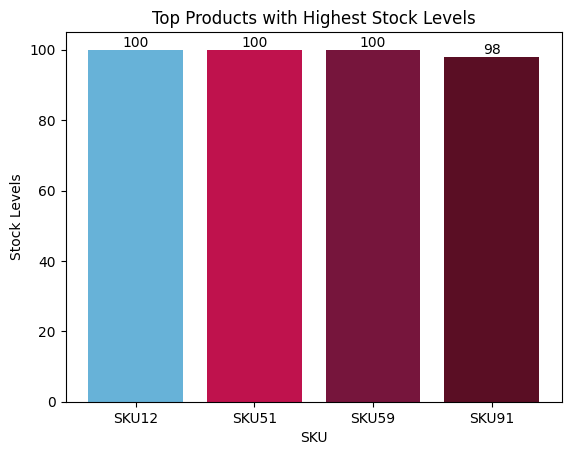

In [180]:
import matplotlib.pyplot as plt

top_high_stock = (
    df_copy[['sku', 'product_type', 'stock_levels']]
    .sort_values(by='stock_levels', ascending=False)
    .head(4)
)

plt.figure()
bars = plt.bar(
    top_high_stock['sku'],
    top_high_stock['stock_levels'],
    color=colors
)

plt.xlabel('SKU')
plt.ylabel('Stock Levels')
plt.title('Top Products with Highest Stock Levels')

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

In [181]:
# BOTTOM 5 PRODUCT WITH PRODUCT TYPE & STOKC LEVLE
df_copy[['sku', 'product_type', 'stock_levels']] \
    .sort_values(by='stock_levels') \
    .head(5)

,sku,product_type,stock_levels
68,SKU68,haircare,0
2,SKU2,haircare,1
34,SKU34,skincare,1
16,SKU16,skincare,2
33,SKU33,cosmetics,4


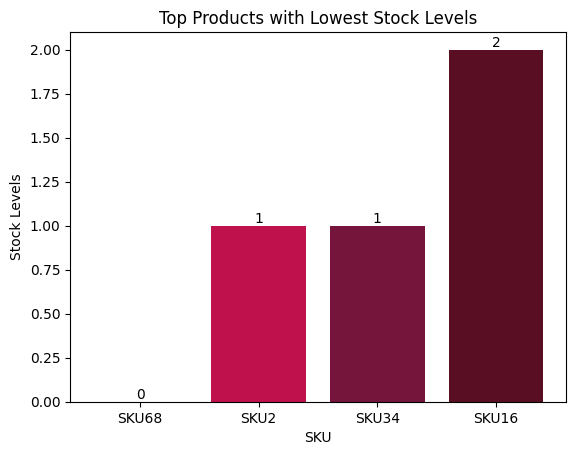

In [182]:
import matplotlib.pyplot as plt

top_low_stock = (
    df_copy[['sku', 'product_type', 'stock_levels']]
    .sort_values(by='stock_levels')
    .head(4)
)

plt.figure()
bars = plt.bar(
    top_low_stock['sku'],
    top_low_stock['stock_levels'],
    color=colors
)

plt.xlabel('SKU')
plt.ylabel('Stock Levels')
plt.title('Top Products with Lowest Stock Levels')

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.show()

In [183]:
# LOW AVALIBILITY WITH STOCK

low_avail_with_stock = df_copy[
    (df_copy['availability'] < 20) &
    (df_copy['stock_levels'] > 0)
][['sku', 'availability', 'stock_levels']]
low_avail_with_stock

,sku,availability,stock_levels
10,SKU10,11,51
13,SKU13,5,80
26,SKU26,9,59
28,SKU28,12,48
29,SKU29,3,45
30,SKU30,10,60
35,SKU35,11,42
37,SKU37,5,25
43,SKU43,6,36
45,SKU45,1,93


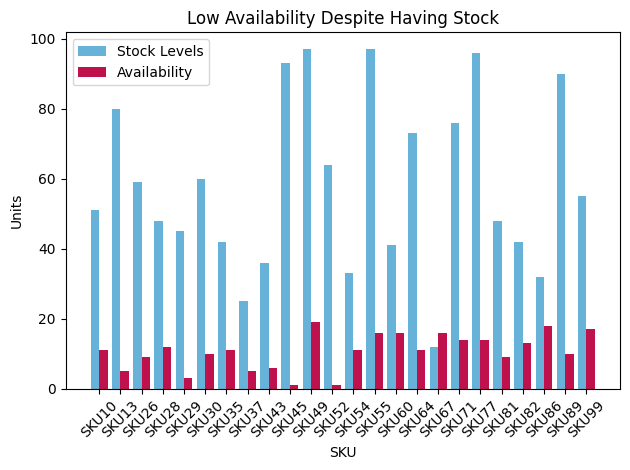

In [249]:
x = np.arange(len(low_avail_with_stock))

# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.bar(
    x - 0.2,
    low_avail_with_stock['stock_levels'],
    width=0.4,
    label='Stock Levels',
    color=colors[0]   # #67B2D8
)

plt.bar(
    x + 0.2,
    low_avail_with_stock['availability'],
    width=0.4,
    label='Availability',
    color=colors[1]   # #BF124D
)

plt.xticks(x, low_avail_with_stock['sku'], rotation=45)
plt.xlabel('SKU')
plt.ylabel('Units')
plt.title('Low Availability Despite Having Stock')

plt.legend()
plt.tight_layout()
plt.show()

High stock out products

In [185]:
high_stockout_risk = df_copy[
    (df_copy['availability'] < 20) &
    (df_copy['stock_levels'] < 50)
][['product_type','sku', 'availability', 'stock_levels']]

In [186]:
high_stockout_count = high_stockout_risk.shape[0]
high_stockout_count

11

In [187]:
high_stockout_risk

,product_type,sku,availability,stock_levels
28,cosmetics,SKU28,12,48
29,cosmetics,SKU29,3,45
35,cosmetics,SKU35,11,42
37,skincare,SKU37,5,25
43,haircare,SKU43,6,36
54,haircare,SKU54,11,33
60,skincare,SKU60,16,41
67,skincare,SKU67,16,12
81,haircare,SKU81,9,48
82,skincare,SKU82,13,42


In [188]:
df_copy.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'order_lead_times', 'order_quantities',
       'shipping_times', 'shipping_carriers', 'shipping_costs',
       'supplier_name', 'location', 'shipping_lead_time', 'production_volumes',
       'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results',
       'defect_rates', 'transportation_modes', 'routes', 'costs',
       'demand_level'],
      dtype='object')

Supplier-wise Inventory Metrics

In [189]:
supplier_inventory = (
    df_copy
    .groupby('supplier_name')
    .agg(
        avg_supply_time=('shipping_times', 'mean'),
        avg_availability=('availability', 'mean'),
        avg_stock_levels=('stock_levels', 'mean')
    )
    .reset_index()
)

supplier_inventory

,supplier_name,avg_supply_time,avg_availability,avg_stock_levels
0,Supplier 1,6.074074,46.407407,42.296296
1,Supplier 2,5.500000,39.681818,46.454545
2,Supplier 3,5.200000,48.933333,43.600000
3,Supplier 4,5.555556,57.944444,58.944444
4,Supplier 5,6.222222,52.055556,49.888889




```
Stockout Model WITH Business Rules
```


In [190]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Target: stockout risk
df_copy['stockout_risk'] = (df_copy['availability'] < 20).astype(int)

X = df_copy.drop(columns=['stockout_risk'])
y = df_copy['stockout_risk']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [191]:
df_copy['model_stockout_warning'] = model.predict(X)

In [192]:
# Thresholds
AVG_SALES = df_copy['number_of_products_sold'].mean()
AVG_shipping_TIME = df_copy['shipping_times'].mean()

# Business checks
df_copy['low_availability'] = df_copy['availability'] < 20
df_copy['high_sales'] = df_copy['number_of_products_sold'] > AVG_SALES
df_copy['high_shipping_time'] = df_copy['shipping_times'] > AVG_shipping_TIME

In [193]:

df_copy['URGENT_STOCK_ACTION'] = (
    (df_copy['model_stockout_warning'] == 1) &
    (df_copy['low_availability']) &
    (df_copy['high_sales'] | df_copy['high_shipping_time'])
)

In [194]:
urgent_stock_list = df_copy[
    df_copy['URGENT_STOCK_ACTION'] == True
][[
    'sku',
    'product_type',
    'availability',
    'number_of_products_sold',
    'manufacturing_lead_time',
    'model_stockout_warning',
    'low_availability',
    'high_sales',
    'high_shipping_time'
]]

urgent_stock_list

,sku,product_type,availability,number_of_products_sold,manufacturing_lead_time,model_stockout_warning,low_availability,high_sales,high_shipping_time
10,SKU10,skincare,11,996,5,1,True,True,False
13,SKU13,skincare,5,249,10,1,True,False,True
29,SKU29,cosmetics,3,253,7,1,True,False,True
30,SKU30,haircare,10,327,30,1,True,False,True
35,SKU35,cosmetics,11,449,2,1,True,False,True
37,SKU37,skincare,5,963,15,1,True,True,True
43,SKU43,haircare,6,598,23,1,True,True,True
45,SKU45,haircare,1,24,25,1,True,False,True
49,SKU49,cosmetics,19,99,28,1,True,False,True
52,SKU52,skincare,1,820,27,1,True,True,False


products that are selling fast and have slow suppliers.

In [195]:
urgent_stock_list[
    (urgent_stock_list['high_sales'] == True) &
    (urgent_stock_list['high_shipping_time'] == True)
]

,sku,product_type,availability,number_of_products_sold,manufacturing_lead_time,model_stockout_warning,low_availability,high_sales,high_shipping_time
37,SKU37,skincare,5,963,15,1,True,True,True
43,SKU43,haircare,6,598,23,1,True,True,True
67,SKU67,skincare,16,513,11,1,True,True,True
71,SKU71,cosmetics,14,637,10,1,True,True,True
99,SKU99,haircare,17,627,2,1,True,True,True


### Suppliers

suppliers and product counts

In [196]:
supplier_product_count = (
    df_copy.groupby('supplier_name')['sku']
           .nunique()
           .reset_index(name='total_products')
           .sort_values(by='total_products', ascending=False)
)

supplier_product_count

,supplier_name,total_products
0,Supplier 1,27
1,Supplier 2,22
3,Supplier 4,18
4,Supplier 5,18
2,Supplier 3,15


- Suppliers handling more products have higher impact on operations.

In [197]:
df_copy.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'order_lead_times', 'order_quantities',
       'shipping_times', 'shipping_carriers', 'shipping_costs',
       'supplier_name', 'location', 'shipping_lead_time', 'production_volumes',
       'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results',
       'defect_rates', 'transportation_modes', 'routes', 'costs',
       'demand_level', 'stockout_risk', 'model_stockout_warning',
       'low_availability', 'high_sales', 'high_shipping_time',
       'URGENT_STOCK_ACTION'],
      dtype='object')

In [198]:
supplier_lead_time = (
    df_copy.groupby('supplier_name')['manufacturing_lead_time']
           .mean()
           .reset_index(name='avg_manufacture_lead_time')
           .sort_values(by='avg_manufacture_lead_time', ascending=False)
)

supplier_lead_time

,supplier_name,avg_manufacture_lead_time
4,Supplier 5,16.333333
1,Supplier 2,15.590909
3,Supplier 4,15.333333
2,Supplier 3,14.933333
0,Supplier 1,12.592593


- Higher lead time = slower supplier

- Slower suppliers increase stockout risk

In [199]:
supplier_availability = (
    df_copy.groupby('supplier_name')['availability']
           .mean()
           .reset_index(name='avg_availability')
           .sort_values(by='avg_availability')
)

supplier_availability

,supplier_name,avg_availability
1,Supplier 2,39.681818
0,Supplier 1,46.407407
2,Supplier 3,48.933333
4,Supplier 5,52.055556
3,Supplier 4,57.944444


- Low availability from a supplier means stock exists but isn’t usable

In [200]:
supplier_inefficiency = (
    df_copy
    .groupby('supplier_name')
    .agg(
        avg_manufacturing_time=('manufacturing_lead_time', 'mean'),
        avg_availability=('availability', 'mean'),
        avg_stock_levels=('stock_levels', 'mean')
    )
    .reset_index()
)

supplier_inefficiency

,supplier_name,avg_manufacturing_time,avg_availability,avg_stock_levels
0,Supplier 1,12.592593,46.407407,42.296296
1,Supplier 2,15.590909,39.681818,46.454545
2,Supplier 3,14.933333,48.933333,43.600000
3,Supplier 4,15.333333,57.944444,58.944444
4,Supplier 5,16.333333,52.055556,49.888889


- Supplier 4 has a long production lead time and keeps higher stock, indicating slower production that requires inventory buffering.

- Suppliers 1, 2, and 3 operate with lower availability, making them more vulnerable to demand spikes and supply disruptions.

- High lead time & Low availability
- stock delays & blocked inventory
- frequent stockout risk

In [201]:
df_copy.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'order_lead_times', 'order_quantities',
       'shipping_times', 'shipping_carriers', 'shipping_costs',
       'supplier_name', 'location', 'shipping_lead_time', 'production_volumes',
       'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results',
       'defect_rates', 'transportation_modes', 'routes', 'costs',
       'demand_level', 'stockout_risk', 'model_stockout_warning',
       'low_availability', 'high_sales', 'high_shipping_time',
       'URGENT_STOCK_ACTION'],
      dtype='object')

In [202]:
supplier_cost = (
    df_copy
    .groupby('supplier_name')['manufacturing_costs']
    .mean()
    .reset_index(name='avg_manufacturing_cost')
    .sort_values(by='avg_manufacturing_cost', ascending=False)
)

supplier_cost

,supplier_name,avg_manufacturing_cost
3,Supplier 4,62.709727
0,Supplier 1,45.254027
4,Supplier 5,44.768243
2,Supplier 3,43.634121
1,Supplier 2,41.622514


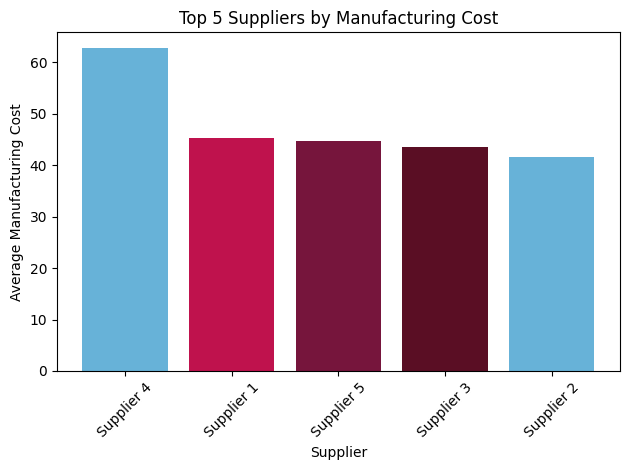

In [250]:

# Select top 5 costly suppliers
top_cost_suppliers = supplier_cost.head(5)

# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.bar(
    top_cost_suppliers['supplier_name'],
    top_cost_suppliers['avg_manufacturing_cost'],
    color=colors[:len(top_cost_suppliers)]
)

plt.xlabel('Supplier')
plt.ylabel('Average Manufacturing Cost')
plt.title('Top 5 Suppliers by Manufacturing Cost')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Supplier 4 has the highest average manufacturing cost This supplier should be reviewed for cost optimization, renegotiation, or value justification (quality, reliability, capacity).

In [204]:
supplier_defects = (
    df_copy
    .groupby('supplier_name')
    .agg(
        avg_defect_rate=('defect_rates', 'mean'),
        inspection_fail_count=('inspection_results', lambda x: (x == 'Fail').sum())
    )
    .reset_index()
    .sort_values(by='avg_defect_rate', ascending=False)
)

supplier_defects

,supplier_name,avg_defect_rate,inspection_fail_count
4,Supplier 5,2.665408,7
2,Supplier 3,2.465786,3
1,Supplier 2,2.362750,8
3,Supplier 4,2.337397,12
0,Supplier 1,1.803630,6


- Supplier 5 and Supplier 3 show the highest average defect rates, indicating consistent quality issues in their production.

- Supplier 4 and Supplier 2 have frequent inspection failures, suggesting weak quality control processes that need immediate improvement or supplier review.

In [205]:
supplier_product_production = (
    df_copy
    .groupby(['supplier_name', 'product_type'])['production_volumes']
    .sum()
    .reset_index(name='total_production_volume')

)

supplier_product_production

,supplier_name,product_type,total_production_volume
0,Supplier 1,cosmetics,2018
1,Supplier 1,haircare,3020
2,Supplier 1,skincare,8507
3,Supplier 2,cosmetics,4681
4,Supplier 2,haircare,5682
5,Supplier 2,skincare,3742
6,Supplier 3,cosmetics,648
7,Supplier 3,haircare,2534
8,Supplier 3,skincare,4815
9,Supplier 4,cosmetics,1984


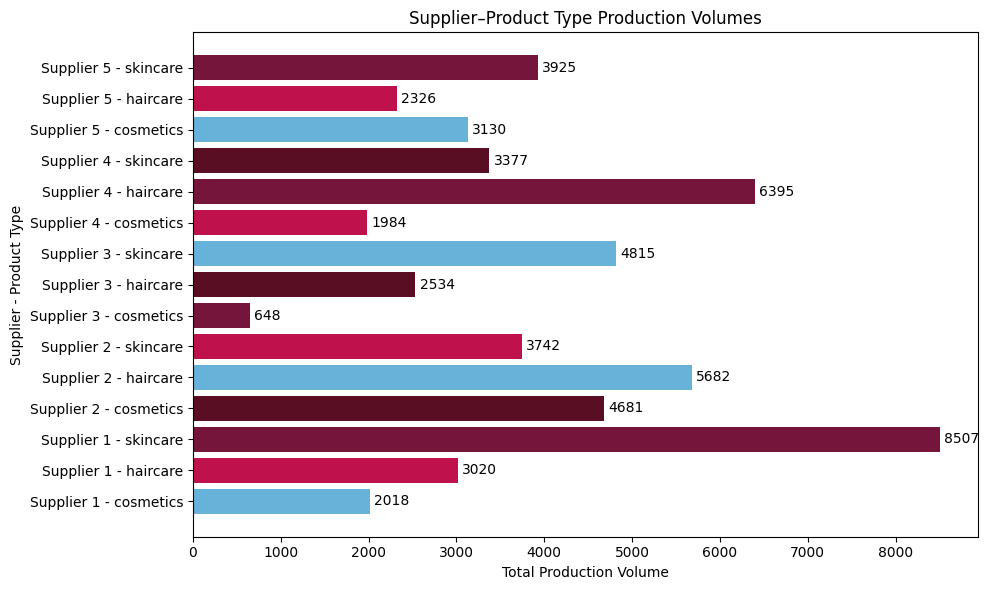

In [251]:
# Top supplier–product combinations
top_supplier_product = supplier_product_production.head(16)

# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_supplier_product['supplier_name'] + ' - ' + top_supplier_product['product_type'],
    top_supplier_product['total_production_volume'],
    color=[colors[i % len(colors)] for i in range(len(top_supplier_product))]
)

plt.xlabel('Total Production Volume')
plt.ylabel('Supplier - Product Type')
plt.title('Supplier–Product Type Production Volumes')

# Add value labels on bars
plt.bar_label(bars, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()

- Supplier 1 is the strongest production partner, driven by exceptionally high skincare output, indicating core dependency and potential single-supplier risk if not diversified.

- Haircare production is concentrated with Suppliers 2 and 4, suggesting these suppliers have specialized capacity or efficiency in this category and should be prioritized for haircare demand scaling.

- Cosmetics production is relatively low and uneven across suppliers, especially for Supplier 3, highlighting a potential capacity gap or underinvestment that could constrain category growth.

In [207]:
product_quality_summary = (
    df_copy
    .groupby('product_type')
    .agg(
        total_production_volume=('production_volumes', 'sum'),
        total_inspections=('inspection_results', 'count'),
        inspection_pass=('inspection_results', lambda x: (x == 'Pass').sum()),
        inspection_fail=('inspection_results', lambda x: (x == 'Fail').sum()),
        inspection_pending=('inspection_results', lambda x: (x == 'Pending').sum())
    )
    .reset_index()
)

product_quality_summary

,product_type,total_production_volume,total_inspections,inspection_pass,inspection_fail,inspection_pending
0,cosmetics,12461,26,6,10,10
1,haircare,19957,34,6,13,15
2,skincare,24366,40,11,13,16


In [208]:
product_quality_summary = (
    df_copy
    .groupby(['product_type', 'supplier_name'])
    .agg(
        total_production_volume=('production_volumes', 'sum'),
        total_inspections=('inspection_results', 'count'),
        inspection_pass=('inspection_results', lambda x: (x == 'Pass').sum()),
        inspection_fail=('inspection_results', lambda x: (x == 'Fail').sum()),
        inspection_pending=('inspection_results', lambda x: (x == 'Pending').sum())
    )
    .reset_index()
)

product_quality_summary

,product_type,supplier_name,total_production_volume,total_inspections,inspection_pass,inspection_fail,inspection_pending
0,cosmetics,Supplier 1,2018,7,2,3,2
1,cosmetics,Supplier 2,4681,7,3,2,2
2,cosmetics,Supplier 3,648,1,0,0,1
3,cosmetics,Supplier 4,1984,4,0,2,2
4,cosmetics,Supplier 5,3130,7,1,3,3
5,haircare,Supplier 1,3020,5,3,1,1
6,haircare,Supplier 2,5682,10,2,4,4
7,haircare,Supplier 3,2534,5,0,1,4
8,haircare,Supplier 4,6395,10,0,7,3
9,haircare,Supplier 5,2326,4,1,0,3


In [209]:
product_supplier_cost = (
    df_copy
    .groupby(['product_type', 'supplier_name'])['manufacturing_costs']
    .mean()
    .reset_index(name='avg_manufacturing_cost')
)

product_supplier_cost

,product_type,supplier_name,avg_manufacturing_cost
0,cosmetics,Supplier 1,44.095979
1,cosmetics,Supplier 2,44.375453
2,cosmetics,Supplier 3,17.803756
3,cosmetics,Supplier 4,49.383064
4,cosmetics,Supplier 5,40.676459
5,haircare,Supplier 1,42.599573
6,haircare,Supplier 2,47.051472
7,haircare,Supplier 3,45.991945
8,haircare,Supplier 4,58.869662
9,haircare,Supplier 5,36.350711


Manufacturing costs vary significantly by supplier within the same product type, with Supplier 3 being the most cost-efficient for cosmetics and Supplier 4 consistently the most expensive, especially in skincare.



In [210]:
supplier_cost_breakdown = (
    df_copy
    .groupby('supplier_name')
    .agg(
        total_manufacturing_cost=('manufacturing_costs', 'sum'),
        total_shipping_cost=('shipping_costs', 'sum'),
        total_other_costs=('costs', 'sum')
    )
    .reset_index()
)

# Calculate total supply chain cost
supplier_cost_breakdown['total_supply_chain_cost'] = (
    supplier_cost_breakdown['total_manufacturing_cost'] +
    supplier_cost_breakdown['total_shipping_cost'] +
    supplier_cost_breakdown['total_other_costs']
)

supplier_cost_breakdown.sort_values(
    by='total_supply_chain_cost', ascending=False
)

,supplier_name,total_manufacturing_cost,total_shipping_cost,total_other_costs,total_supply_chain_cost
0,Supplier 1,1221.858734,148.832149,15520.980745,16891.671629
1,Supplier 2,915.695312,126.261917,11330.599298,12372.556527
3,Supplier 4,1128.775084,103.672314,9392.587517,10625.034915
4,Supplier 5,805.828374,104.216968,9648.409132,10558.454474
2,Supplier 3,654.511820,71.831559,7032.001523,7758.344902


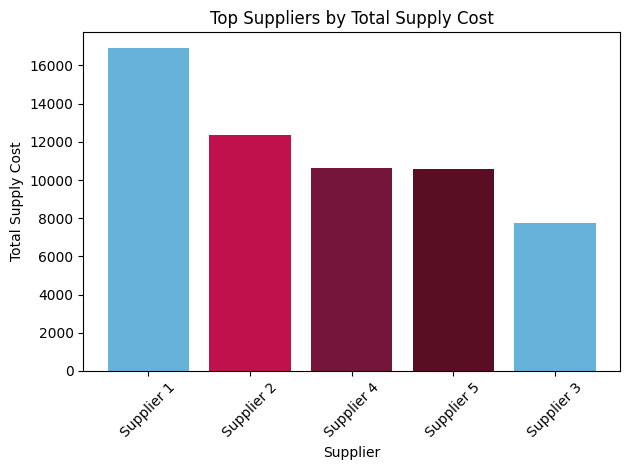

In [252]:
# Select top 5 suppliers by total supply chain cost
top_cost_suppliers = supplier_cost_breakdown.sort_values(
    by='total_supply_chain_cost',
    ascending=False
).head(5)

# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.bar(
    top_cost_suppliers['supplier_name'],
    top_cost_suppliers['total_supply_chain_cost'],
    color=colors[:len(top_cost_suppliers)]
)

plt.xlabel('Supplier')
plt.ylabel('Total Supply Cost')
plt.title('Top Suppliers by Total Supply Cost')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [212]:
df_copy.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'order_lead_times', 'order_quantities',
       'shipping_times', 'shipping_carriers', 'shipping_costs',
       'supplier_name', 'location', 'shipping_lead_time', 'production_volumes',
       'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results',
       'defect_rates', 'transportation_modes', 'routes', 'costs',
       'demand_level', 'stockout_risk', 'model_stockout_warning',
       'low_availability', 'high_sales', 'high_shipping_time',
       'URGENT_STOCK_ACTION'],
      dtype='object')

In [213]:


supplier_features = (
    df_copy
    .groupby('supplier_name')
    .agg(
        avg_manufacturing_time=('manufacturing_lead_time', 'mean'),
        avg_availability=('availability', 'mean'),
        avg_manufacturing_cost=('manufacturing_costs', 'mean'),
        avg_defect_rate=('defect_rates', 'mean'),
        avg_shipping_cost=('shipping_costs', 'mean')
    )
)

In [214]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(supplier_features)

In [215]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
supplier_features['cluster'] = kmeans.fit_predict(scaled_features)

In [216]:
supplier_clusters = supplier_features.reset_index()
supplier_clusters

,supplier_name,avg_manufacturing_time,avg_availability,avg_manufacturing_cost,avg_defect_rate,avg_shipping_cost,cluster
0,Supplier 1,12.592593,46.407407,45.254027,1.803630,5.512302,2
1,Supplier 2,15.590909,39.681818,41.622514,2.362750,5.739178,0
2,Supplier 3,14.933333,48.933333,43.634121,2.465786,4.788771,0
3,Supplier 4,15.333333,57.944444,62.709727,2.337397,5.759573,1
4,Supplier 5,16.333333,52.055556,44.768243,2.665408,5.789832,0


- Cluster 0 → Fast, reliable, low defect suppliers

- Cluster 1 → Slow, high cost, high defect suppliers

- Cluster 2 → Medium performance suppliers

### Manufacturing / Logistic

In [217]:
df_copy['shipping_times'].describe()

,shipping_times
count,100.000000
mean,5.750000
std,2.724283
min,1.000000
25%,3.750000
50%,6.000000
75%,8.000000
max,10.000000


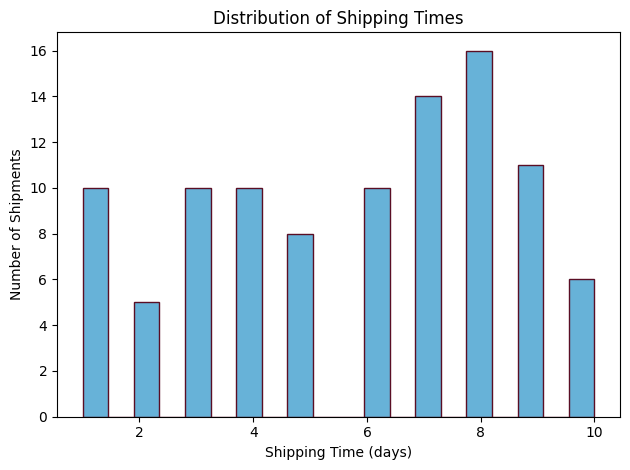

In [253]:
# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.hist(
    df_copy['shipping_times'],
    bins=20,
    color=colors[0],      # #67B2D8
    edgecolor=colors[3]  # #5A0E24
)

plt.xlabel('Shipping Time (days)')
plt.ylabel('Number of Shipments')
plt.title('Distribution of Shipping Times')

plt.tight_layout()
plt.show()

In [219]:
mode_usage = (
    df_copy['transportation_modes']
    .value_counts()
    .reset_index()
)

mode_usage.columns = ['transportation_mode', 'usage_count']
mode_usage

,transportation_mode,usage_count
0,Road,29
1,Rail,28
2,Air,26
3,Sea,17


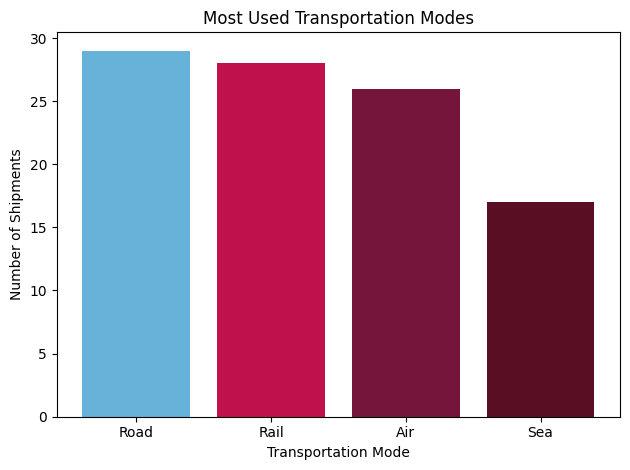

In [254]:
 # Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.bar(
    mode_usage['transportation_mode'],
    mode_usage['usage_count'],
    color=[colors[i % len(colors)] for i in range(len(mode_usage))]
)

plt.xlabel('Transportation Mode')
plt.ylabel('Number of Shipments')
plt.title('Most Used Transportation Modes')

plt.tight_layout()
plt.show()


In [221]:
mode_shipping_cost = (
    df_copy
    .groupby('transportation_modes')['shipping_costs']
    .mean()
    .reset_index(name='avg_shipping_cost')
    .sort_values(by='avg_shipping_cost', ascending=False)
)

mode_shipping_cost

,transportation_modes,avg_shipping_cost
0,Air,6.017839
2,Road,5.542115
1,Rail,5.469098
3,Sea,4.970294


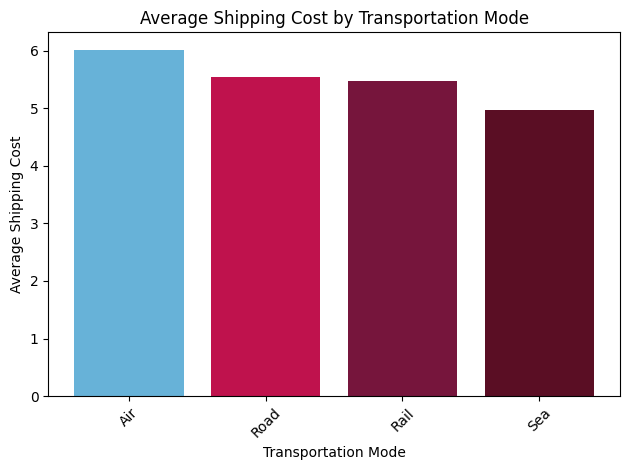

In [255]:
# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.bar(
    mode_shipping_cost['transportation_modes'],
    mode_shipping_cost['avg_shipping_cost'],
    color=[colors[i % len(colors)] for i in range(len(mode_shipping_cost))]
)

plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Cost')
plt.title('Average Shipping Cost by Transportation Mode')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [223]:
mode_delivery_stats = (
    df_copy
    .groupby('transportation_modes')['shipping_times']
    .agg(
        avg_shipping_time='mean',
        max_shipping_time='max',
        min_shipping_time='min'
    )
    .reset_index()
)

mode_delivery_stats

,transportation_modes,avg_shipping_time,max_shipping_time,min_shipping_time
0,Air,5.115385,10,1
1,Rail,6.571429,10,1
2,Road,4.724138,9,1
3,Sea,7.117647,10,2


In [224]:
mode_delivery_time = (
    df_copy
    .groupby('transportation_modes')['shipping_times']
    .mean()
    .reset_index(name='avg_shipping_time')
    .sort_values(by='avg_shipping_time')
)

mode_delivery_time

,transportation_modes,avg_shipping_time
2,Road,4.724138
0,Air,5.115385
1,Rail,6.571429
3,Sea,7.117647


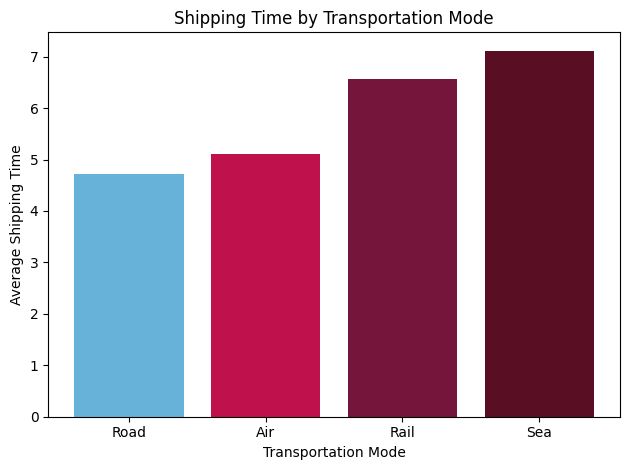

In [256]:
# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.bar(
    mode_delivery_time['transportation_modes'],
    mode_delivery_time['avg_shipping_time'],
    color=[colors[i % len(colors)] for i in range(len(mode_delivery_time))]
)

plt.xlabel('Transportation Mode')
plt.ylabel('Average Shipping Time')
plt.title('Shipping Time by Transportation Mode')

plt.tight_layout()
plt.show()

This calculation shows ROAD transportation mode delivers faster or SEA slower on average.

In [226]:
mode_availability = (
    df_copy
    .groupby('transportation_modes')['availability']
    .mean()
    .reset_index(name='avg_availability')
    .sort_values(by='avg_availability', ascending=False)
)

mode_availability

,transportation_modes,avg_availability
2,Road,54.310345
0,Air,48.115385
3,Sea,46.000000
1,Rail,44.000000


Availability differs across transportation modes, indicating varying delivery reliability.

In [227]:
mode_cost_time = (
    df_copy
    .groupby('transportation_modes')
    .agg(
        avg_shipping_cost=('shipping_costs', 'mean'),
        avg_shipping_time=('shipping_times', 'mean')
    )
    .reset_index()
)

mode_cost_time

,transportation_modes,avg_shipping_cost,avg_shipping_time
0,Air,6.017839,5.115385
1,Rail,5.469098,6.571429
2,Road,5.542115,4.724138
3,Sea,4.970294,7.117647


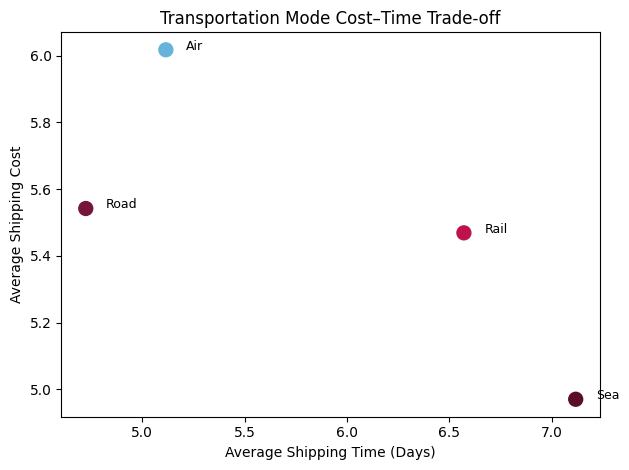

In [257]:
# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.scatter(
    mode_cost_time['avg_shipping_time'],
    mode_cost_time['avg_shipping_cost'],
    color=[colors[i % len(colors)] for i in range(len(mode_cost_time))],
    s=100
)

# Add mode labels near points
for i, mode in enumerate(mode_cost_time['transportation_modes']):
    plt.text(
        mode_cost_time['avg_shipping_time'][i] + 0.1,
        mode_cost_time['avg_shipping_cost'][i],
        mode,
        fontsize=9
    )

plt.xlabel('Average Shipping Time (Days)')
plt.ylabel('Average Shipping Cost')
plt.title('Transportation Mode Cost–Time Trade-off')

plt.tight_layout()
plt.show()

In [229]:
carrier_usage = (
    df_copy['shipping_carriers']
    .value_counts()
    .reset_index()
)

carrier_usage.columns = ['shipping_carrier', 'shipment_count']
carrier_usage

,shipping_carrier,shipment_count
0,Carrier B,43
1,Carrier C,29
2,Carrier A,28


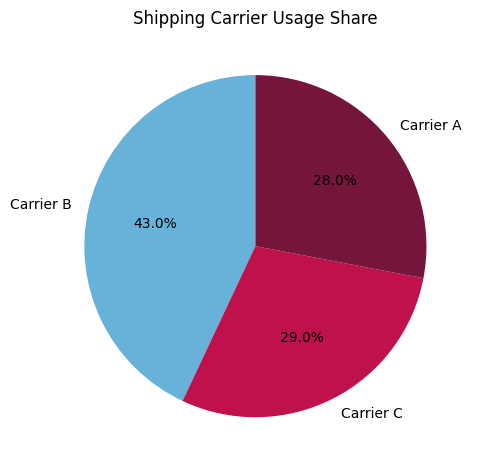

In [259]:
# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.pie(
    carrier_usage['shipment_count'],
    labels=carrier_usage['shipping_carrier'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[i % len(colors)] for i in range(len(carrier_usage))]
)

plt.title('Shipping Carrier Usage Share')
plt.tight_layout()
plt.show()

In [231]:
carrier_delivery_time = (
    df_copy
    .groupby('shipping_carriers')['shipping_times']
    .mean()
    .reset_index(name='avg_delivery_time')
    .sort_values(by='avg_delivery_time')
)

carrier_delivery_time

,shipping_carriers,avg_delivery_time
1,Carrier B,5.302326
2,Carrier C,6.034483
0,Carrier A,6.142857


In [232]:
carrier_cost = (
    df_copy
    .groupby('shipping_carriers')['shipping_costs']
    .sum()
    .reset_index(name='total_logistics_cost')
    .sort_values(by='total_logistics_cost', ascending=False)
)

carrier_cost

,shipping_carriers,total_logistics_cost
1,Carrier B,236.897620
2,Carrier C,162.379457
0,Carrier A,155.537831


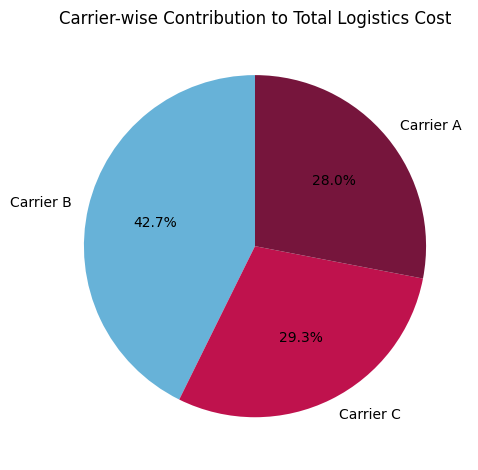

In [262]:
# Your given color codes
colors = ['#67B2D8', '#BF124D', '#76153C', '#5A0E24']

plt.figure()

plt.pie(
    carrier_cost['total_logistics_cost'],
    labels=carrier_cost['shipping_carriers'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[colors[i % len(colors)] for i in range(len(carrier_cost))]
)

plt.title('Carrier-wise Contribution to Total Logistics Cost')
plt.tight_layout()
plt.show()

In [234]:
carrier_cost_time = (
    df_copy
    .groupby('shipping_carriers')
    .agg(
        avg_shipping_cost=('shipping_costs', 'mean'),
        avg_delivery_time=('shipping_times', 'mean')
    )
    .reset_index()
)

carrier_cost_time

,shipping_carriers,avg_shipping_cost,avg_delivery_time
0,Carrier A,5.554923,6.142857
1,Carrier B,5.509247,5.302326
2,Carrier C,5.599292,6.034483


Balanced carriers (low cost + reasonable speed)

In [235]:
route_usage = (
    df_copy['routes']
    .value_counts()
    .reset_index()
)

route_usage.columns = ['route', 'shipment_count']
route_usage

,route,shipment_count
0,Route A,43
1,Route B,37
2,Route C,20


In [236]:
route_usage = (
    df_copy[['transportation_modes', 'routes']]
    .value_counts()
    .reset_index(name='shipment_count')
)

route_usage.columns = ['transportation_modes', 'route', 'shipment_count']

route_usage = route_usage.sort_values(
    by=['transportation_modes', 'shipment_count'],
    ascending=[True, False]
)

route_usage

,transportation_modes,route,shipment_count
3,Air,Route A,11
5,Air,Route C,8
6,Air,Route B,7
0,Rail,Route A,14
2,Rail,Route B,11
11,Rail,Route C,3
1,Road,Route B,13
4,Road,Route A,11
9,Road,Route C,5
7,Sea,Route A,7


In [237]:

route_delivery_time = (
    df_copy
    .groupby('routes')['shipping_times']
    .mean()
    .reset_index(name='avg_delivery_time')
    .sort_values(by='avg_delivery_time', ascending=False)
)

route_delivery_time

,routes,avg_delivery_time
0,Route A,6.023256
1,Route B,5.702703
2,Route C,5.250000


In [238]:
route_cost_time = (
    df_copy
    .groupby('routes')
    .agg(
        avg_shipping_cost=('shipping_costs', 'mean'),
        avg_delivery_time=('shipping_times', 'mean')
    )
    .reset_index()
)

route_cost_time

,routes,avg_shipping_cost,avg_delivery_time
0,Route A,5.379699,6.023256
1,Route B,5.551986,5.702703
2,Route C,5.903218,5.250000


In [239]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

route_features = route_cost_time[['avg_shipping_cost', 'avg_delivery_time']]

scaler = StandardScaler()
scaled_routes = scaler.fit_transform(route_features)

In [240]:
kmeans = KMeans(n_clusters=3, random_state=42)
route_cost_time['route_cluster'] = kmeans.fit_predict(scaled_routes)

route_cost_time

,routes,avg_shipping_cost,avg_delivery_time,route_cluster
0,Route A,5.379699,6.023256,2
1,Route B,5.551986,5.702703,0
2,Route C,5.903218,5.250000,1


- Route C offers faster delivery but at a higher cost, while Route A is slower with moderate cost, indicating different efficiency trade-offs across clusters.

- Route B represents a balanced option, with moderate cost and delivery time, making it suitable as a standard route for regular shipments.

- Assign urgent shipments to faster clusters (like Route C).

- Use balanced clusters (like Route B) for routine deliveries.

- Review or optimize slower clusters (like Route A) to improve performance or reduce cost.

In [241]:
carrier_route_efficiency = (
    df_copy
    .groupby(['shipping_carriers', 'routes'])
    .agg(
        avg_shipping_cost=('shipping_costs', 'mean'),
        avg_delivery_time=('shipping_times', 'mean')
    )
    .reset_index()
)

carrier_route_efficiency['cost_time_ratio'] = (
    carrier_route_efficiency['avg_shipping_cost'] /
    carrier_route_efficiency['avg_delivery_time']
)

carrier_route_efficiency.sort_values(by='cost_time_ratio').head()

,shipping_carriers,routes,avg_shipping_cost,avg_delivery_time,cost_time_ratio
8,Carrier C,Route C,5.564702,8.142857,0.683384
0,Carrier A,Route A,4.629630,6.250000,0.740741
4,Carrier B,Route B,5.174455,6.000000,0.862409
6,Carrier C,Route A,5.839868,6.142857,0.950676
3,Carrier B,Route A,5.530197,5.764706,0.959320


Certain carrier–route pairs deliver lowest cost without delays.

In [242]:
df_copy.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'order_lead_times', 'order_quantities',
       'shipping_times', 'shipping_carriers', 'shipping_costs',
       'supplier_name', 'location', 'shipping_lead_time', 'production_volumes',
       'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results',
       'defect_rates', 'transportation_modes', 'routes', 'costs',
       'demand_level', 'stockout_risk', 'model_stockout_warning',
       'low_availability', 'high_sales', 'high_shipping_time',
       'URGENT_STOCK_ACTION'],
      dtype='object')

In [243]:
location_cost = (
    df_copy
    .groupby('location')['shipping_costs']
    .mean()
    .reset_index(name='avg_shipping_cost')
    .sort_values(by='avg_shipping_cost', ascending=False)
)

location_cost

,location,avg_shipping_cost
4,Mumbai,6.248989
3,Kolkata,5.761414
0,Bangalore,5.748445
2,Delhi,5.069881
1,Chennai,4.689079


In [244]:
location_shipping = (
    df_copy
    .groupby('location')['shipping_times']
    .mean()
    .reset_index(name='avg_shipping_time')
    .sort_values(by='avg_shipping_time', ascending=False)
)

location_shipping

,location,avg_shipping_time
1,Chennai,6.000000
3,Kolkata,5.960000
2,Delhi,5.933333
4,Mumbai,5.545455
0,Bangalore,5.277778


In [245]:
avg_production_volume = df_copy['production_volumes'].mean()
avg_production_volume

np.float64(567.84)

In [246]:
df_copy.groupby('product_type')['production_volumes'].mean()

,production_volumes
product_type,
cosmetics,479.269231
haircare,586.970588
skincare,609.150000


In [247]:
inspection_percentage = (
    df_copy['inspection_results']
    .value_counts(normalize=True) * 100
).reset_index()

inspection_percentage.columns = ['inspection_result', 'percentage']
inspection_percentage

,inspection_result,percentage
0,Pending,41.0
1,Fail,36.0
2,Pass,23.0


In [248]:
prod_defect_corr = df_copy[['production_volumes', 'defect_rates']].corr()
prod_defect_corr

,production_volumes,defect_rates
production_volumes,1.000000,0.118853
defect_rates,0.118853,1.000000


The value 0.1189 shows a very weak positive relationship between production volume and defect rate.

This means that when production increases, defect rates increase only slightly.